# Fitting 1 Granule

# PACE v3

## https://oceancolor.gsfc.nasa.gov/data/reprocessing/V3.0/pace/

## Grab data here:

### https://search.earthdata.nasa.gov/search/granules?portal=obdaac&p=C3385049983-OB_CLOUD&pg[0][v]=f&pg[0][qt]=%2C2025-04-01T23%3A59%3A59.999Z&pg[0][gsk]=-start_date&g=G3505010983-OB_CLOUD&q=pace%20oci&tl=1730157016.405!4!!&lat=19.493155&long=-116.09832978233831&zoom=5.260164420645015

In [59]:
# imports
from importlib import reload
import os
import numpy as np

from matplotlib import pyplot as plt

import xarray

from ocpy.pace import io as pace_io
from ocpy.utils import plotting

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting

# Inspect granule

In [2]:
gfile = os.path.join(os.getenv('OS_COLOR'), 'PACE', 'Granules', 'PACE_OCI.20250401T202905.L2.OC_AOP.V3_0.nc')

## Try xarray

In [3]:
ds = xarray.open_dataset(gfile)

In [4]:
ds

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20250401T202905.L2.OC_AOP.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data2/sdpsoper/vdc/vpu21/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -101.80601
    geospatial_lon_min:                -131.308
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0011428594589233

## Home grown

In [5]:
xds, flags = pace_io.load_oci_l2(gfile)

In [6]:
xds

<xarray.Dataset> Size: 3GB
Dimensions:     (x: 1710, y: 1272, wl: 172)
Coordinates:
    latitude    (x, y) float32 9MB 8.01 8.02 8.03 8.04 ... 30.95 30.97 30.98
    longitude   (x, y) float32 9MB -125.9 -125.9 -125.8 ... -104.5 -104.5 -104.4
    wavelength  (wl) int32 688B 346 348 351 353 356 358 ... 712 713 714 717 719
Dimensions without coordinates: x, y, wl
Data variables:
    Rrs         (x, y, wl) float32 1GB -3.277e+04 -3.277e+04 ... -3.277e+04
    Rrs_unc     (x, y, wl) float32 1GB -3.277e+04 -3.277e+04 ... -3.277e+04
Attributes: (12/45)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20250401T202905.L2.OC_AOP.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data2/sdpsoper/vdc/vpu21/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -101.80601
    geospatial_lon_min:                -131.308
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0011428594589233

# Plot one

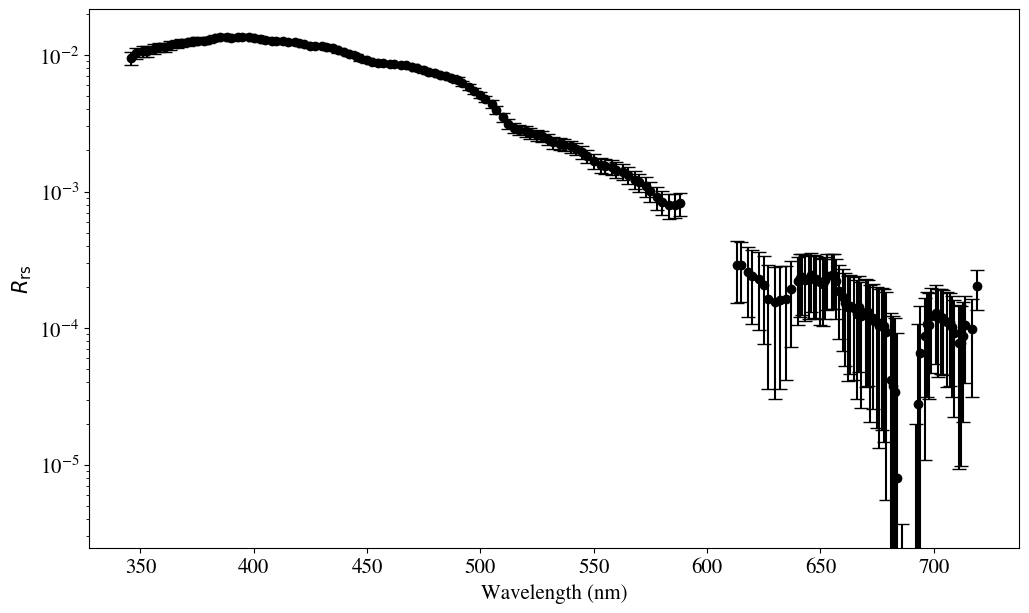

In [7]:
ix,iy = 1000, 200
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
#
ax.errorbar(xds.wavelength, xds.Rrs[ix,iy,:], yerr=xds.Rrs_unc[ix,iy,:],
                color='k',  fmt='o', capsize=5) 
#
ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

# Fit one

## Parse out the data

In [35]:
ix, iy = 1000, 200
gd_wave = (xds.wavelength.data >= 400.) &  (xds.wavelength.data <= 700.) 
iwave = xds.wavelength.data[gd_wave]
ispec = xds.Rrs.data[ix,iy,gd_wave]
isig = xds.Rrs_unc.data[ix,iy,gd_wave]

In [36]:
iwave

array([400, 403, 405, 408, 410, 413, 415, 418, 420, 422, 425, 427, 430,
       432, 435, 437, 440, 442, 445, 447, 450, 452, 455, 457, 460, 462,
       465, 467, 470, 472, 475, 477, 480, 482, 485, 487, 490, 492, 495,
       497, 500, 502, 505, 507, 510, 512, 515, 517, 520, 522, 525, 527,
       530, 532, 535, 537, 540, 542, 545, 547, 550, 553, 555, 558, 560,
       563, 565, 568, 570, 573, 575, 578, 580, 583, 586, 588, 613, 615,
       618, 620, 623, 625, 627, 630, 632, 635, 637, 640, 641, 642, 643,
       645, 646, 647, 648, 650, 651, 652, 653, 655, 656, 657, 658, 660,
       661, 662, 663, 665, 666, 667, 668, 670, 671, 672, 673, 675, 676,
       677, 678, 679, 681, 682, 683, 684, 686, 687, 688, 689, 691, 692,
       693, 694, 696, 697, 698, 699], dtype=int32)

## Parameters

In [37]:
p = standard.expb_pow()
p

BING20_tuple(model_names=['ExpBricaud', 'Pow'], scl_noise='PACE', wv_min=400.0, wv_max=700.0, satellite='PACE', add_noise=False, apriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.01, 'pmax': 0.02}, {'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}], bpriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.0, 'pmax': 2.0}], set_Sdg=False, sSdg=0.002, beta=None, nMC=None, nsteps=40000, nburn=1000)

## Models

In [38]:
# Models
models = model_utils.init(p.model_names, iwave)

In [39]:
models

[<aNWModel: ExpBricaud, nparam=3>, <bbNWModel: Pow, nparam=2>]

## Priors

In [40]:
bing_priors.set_standard_priors(models, p)

## Initialize the MCMC

In [41]:
pdict = bing_inf.init_mcmc(models, nsteps=p.nsteps, nburn=p.nburn)

In [42]:
pdict['Chl'] = np.array([0.1 / 0.05582])
pdict['Y'] = None

## Items

In [54]:
#p0 = [0.1, 0.15, 0.1, 0.1, 1.5]
p0 = ans.tolist()
items = [(ispec, isig**2, p0, 0)]

## Fit me

## Check me

In [55]:
chains, idx = bing_inf.fit_one(
        items[0], models=models, pdict=pdict, chains_only=True)

idx=0
Running burn-in


  0%|                                                 | 0/1000 [00:00<?, ?it/s]/home/xavier/miniconda3/envs/os_313/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 2837.87it/s]


Running full model


100%|██████████████████████████████████| 40000/40000 [00:12<00:00, 3096.72it/s]


In [56]:
chains.shape

(40000, 16, 5)

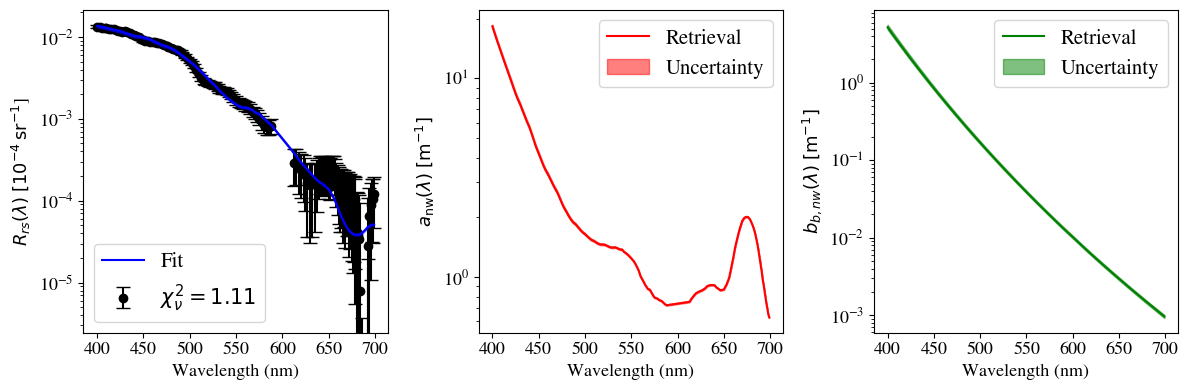

In [66]:
reload(bing_plotting)
bing_plotting.show_fits(models, chains,  None, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                        log_abb=True,
                   #Rrs_true=dict(wave=df_lee.wave, spec=gordon_Rrs_1),
                #anw_true=anw_dict, bbnw_true=bbnw_dict,
                )
plt.show()

# Try chi^2

In [46]:
ans, cov, idx = chisq_fit.fit(items[0], models)

In [47]:
ans

array([ 1.22063641,  0.03858002,  0.32779865, -1.9913909 , 15.37485451])

In [67]:
models[0].pnames, models[1].pnames

(['Adg', 'Sdg', 'Aph'], ['Bnw', 'beta'])

### Show

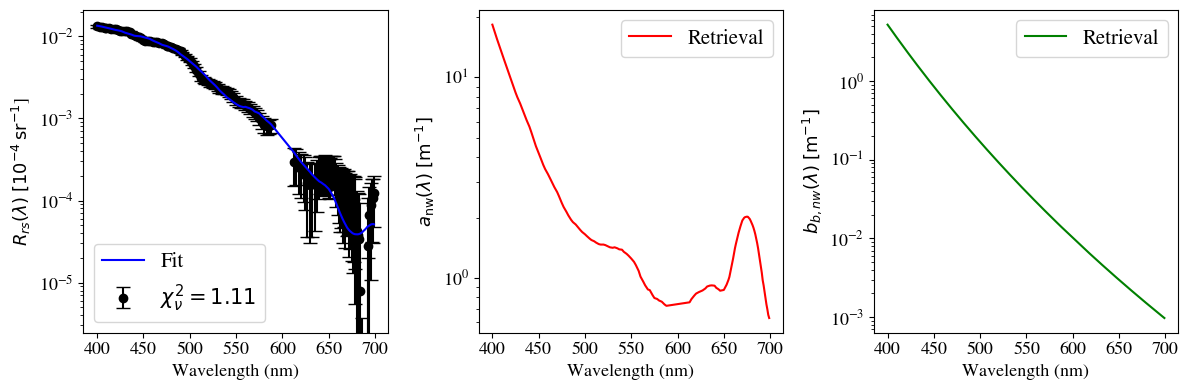

In [65]:
reload(bing_plotting)
Chl = 10**ans[-1] / 0.05582
bing_plotting.show_fits(models, ans,  Chl, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                    log_abb=True,
                        
                   #Rrs_true=dict(wave=df_lee.wave, spec=gordon_Rrs_1),
                #anw_true=anw_dict, bbnw_true=bbnw_dict,
                )
plt.show()

In [49]:
models[0].uses_Chl

True

----

In [43]:
burn, thin = 7000, 1

In [44]:
cchains = chains[burn::thin, :, :].reshape(-1, chains.shape[-1])

In [45]:
cchains.shape

(528000, 5)